# CH 6 : SUMMARY OF FINDINGS REGARDING THE DATA-MINING BIAS

> **L’Eurêka final :** un backtest optimisé n’est pas une estimation neutre de la performance future. C’est le résultat d’une compétition statistique où la meilleure règle a souvent gagné grâce à un mélange de **mérite réel** et de **chance favorable**.

Ce notebook transforme la synthèse EBTA sur le **biais de minage de données** en intuition visuelle et en code Python.

L’objectif est simple : montrer pourquoi la performance observée du meilleur backtest est presque toujours supérieure à sa performance attendue future, puis comprendre comment trois leviers modifient ce biais :

- le nombre de règles testées ;
- le nombre d’observations disponibles ;
- la présence ou non d’un vrai mérite dans certaines règles.


## 1. Le problème central

Dans une recherche de stratégie, on teste souvent plusieurs règles puis on garde celle qui a le meilleur résultat historique.

Cela semble rationnel, mais statistiquement il y a un piège :

$$
P_{obs} = P_{réel} + H
$$

où :

- $P_{obs}$ est la **performance observée** en backtest ;
- $P_{réel}$ est le **mérite réel** ou l’espérance future ;
- $H$ est la composante de **hasard** liée à l’échantillon historique.

Quand on choisit la meilleure règle parmi beaucoup de candidates, on ne choisit pas seulement la règle avec le meilleur mérite. On choisit aussi celle qui a reçu le plus de chance positive sur le passé.

> La sélection du meilleur backtest sélectionne aussi une partie du hasard.


## 2. Intuition avec un univers de règles sans mérite

Supposons d’abord que toutes les règles soient nulles.

Chaque règle a une performance réelle égale à zéro :

$$
P_{réel}=0
$$

Pourtant, sur un échantillon historique limité, certaines règles auront une performance positive par hasard, d’autres négative.

Si l’on teste 10, 100 ou 1 000 règles et que l’on garde la meilleure, la meilleure règle affichera presque toujours une performance positive.

Ce profit observé est donc un **mirage statistique**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

def simulate_best_rule_bias(
    n_rules=100,
    n_obs=100,
    true_mean=0.0,
    noise_std=1.0,
    n_experiments=5000,
):
    """
    Simule un univers de règles de trading.

    Chaque expérience :
    - génère n_rules historiques de performance ;
    - calcule la moyenne observée de chaque règle ;
    - sélectionne la meilleure règle observée ;
    - mesure son biais : performance observée - performance réelle.

    Ici, toutes les règles ont le même mérite réel true_mean.
    """
    samples = rng.normal(
        loc=true_mean,
        scale=noise_std,
        size=(n_experiments, n_rules, n_obs)
    )

    observed_means = samples.mean(axis=2)
    best_observed = observed_means.max(axis=1)
    bias = best_observed - true_mean

    return pd.DataFrame({
        "best_observed_performance": best_observed,
        "data_mining_bias": bias
    })

df_null = simulate_best_rule_bias(n_rules=100, n_obs=100)

df_null.describe()


,best_observed_performance,data_mining_bias
count,5000.000000,5000.000000
mean,0.251411,0.251411
std,0.042954,0.042954
min,0.134289,0.134289
25%,0.220685,0.220685
50%,0.246930,0.246930
75%,0.277636,0.277636
max,0.484052,0.484052


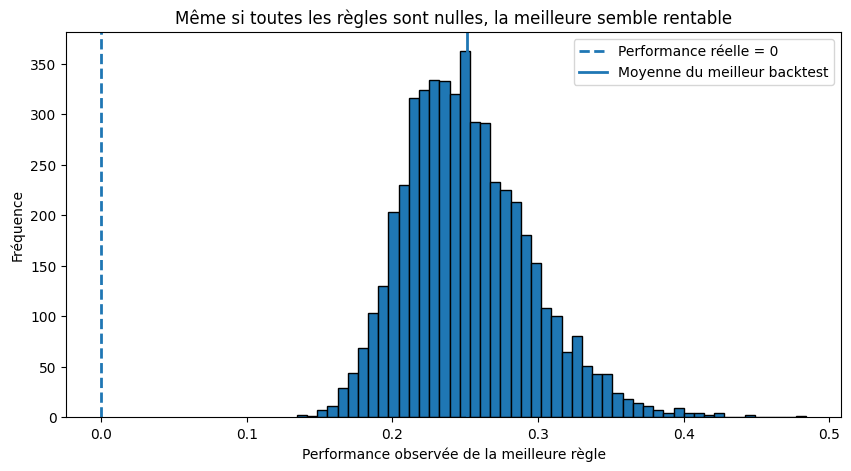

In [2]:
plt.figure(figsize=(10, 5))
plt.hist(df_null["best_observed_performance"], bins=50, edgecolor="black")
plt.axvline(0, linestyle="--", linewidth=2, label="Performance réelle = 0")
plt.axvline(df_null["best_observed_performance"].mean(), linestyle="-", linewidth=2, label="Moyenne du meilleur backtest")
plt.title("Même si toutes les règles sont nulles, la meilleure semble rentable")
plt.xlabel("Performance observée de la meilleure règle")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


## 3. Effet du nombre de règles testées

Plus on teste de règles, plus on donne au hasard l’occasion de produire un résultat extrême.

En termes EBTA, le nombre de règles testées augmente la probabilité de tomber sur un **outlier positif**.

On peut résumer l’idée ainsi :

$$
	ext{plus de règles testées} \Rightarrow 	ext{plus de chances de trouver un faux gagnant}
$$

Ce n’est pas parce que l’univers contient plus d’alpha. C’est aussi parce que l’univers contient plus d’occasions de sélectionner de la chance.


In [3]:
rule_counts = [1, 5, 10, 30, 100, 300, 1000]
rows = []

for n_rules in rule_counts:
    df = simulate_best_rule_bias(n_rules=n_rules, n_obs=100, true_mean=0.0, n_experiments=3000)
    rows.append({
        "Nombre de règles testées": n_rules,
        "Biais moyen": df["data_mining_bias"].mean(),
        "Performance médiane du gagnant": df["best_observed_performance"].median(),
    })

bias_by_rules = pd.DataFrame(rows)
bias_by_rules


,Nombre de règles testées,Biais moyen,Performance médiane du gagnant
0,1,0.002156,0.000554
1,5,0.114570,0.110710
2,10,0.156803,0.151974
3,30,0.203900,0.199718
4,100,0.250816,0.246766
5,300,0.288387,0.283561
6,1000,0.324759,0.320005


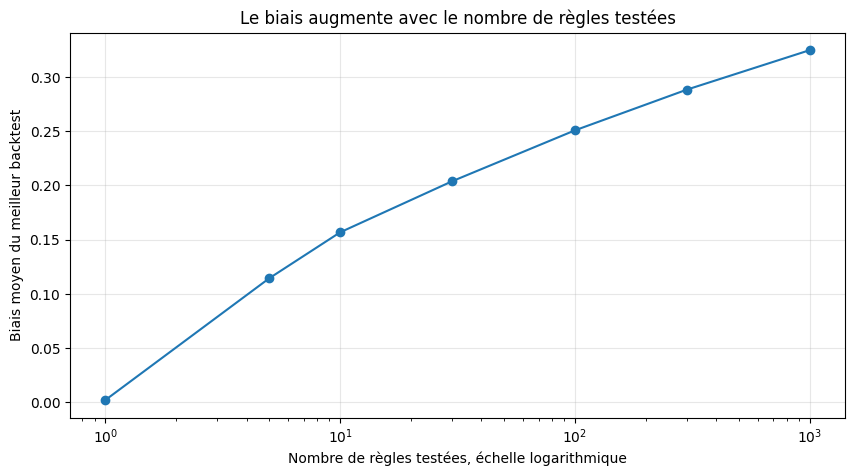

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(
    bias_by_rules["Nombre de règles testées"],
    bias_by_rules["Biais moyen"],
    marker="o"
)
plt.xscale("log")
plt.title("Le biais augmente avec le nombre de règles testées")
plt.xlabel("Nombre de règles testées, échelle logarithmique")
plt.ylabel("Biais moyen du meilleur backtest")
plt.grid(True, alpha=0.3)
plt.show()


## 4. Effet du nombre d’observations

Le nombre d’observations $N$ est le grand régulateur du biais.

Quand $N$ augmente, la moyenne observée de chaque règle devient plus stable. La loi des grands nombres force la performance observée à se rapprocher de la performance réelle.

$$
N \uparrow \Rightarrow \text{variance de la moyenne observée} \downarrow
$$

En pratique, cela veut dire qu’une règle nulle a moins de chances d’afficher accidentellement une performance extrême si elle est testée sur un grand historique.


In [5]:
obs_counts = [10, 20, 50, 100, 200, 500, 1000]
rows = []

for n_obs in obs_counts:
    df = simulate_best_rule_bias(n_rules=100, n_obs=n_obs, true_mean=0.0, n_experiments=3000)
    rows.append({
        "Nombre d'observations": n_obs,
        "Biais moyen": df["data_mining_bias"].mean(),
        "Performance médiane du gagnant": df["best_observed_performance"].median(),
    })

bias_by_obs = pd.DataFrame(rows)
bias_by_obs


,Nombre d'observations,Biais moyen,Performance médiane du gagnant
0,10,0.796308,0.781839
1,20,0.560247,0.550377
2,50,0.354078,0.346883
3,100,0.251385,0.246722
4,200,0.177892,0.174196
5,500,0.111793,0.109833
6,1000,0.079281,0.077792


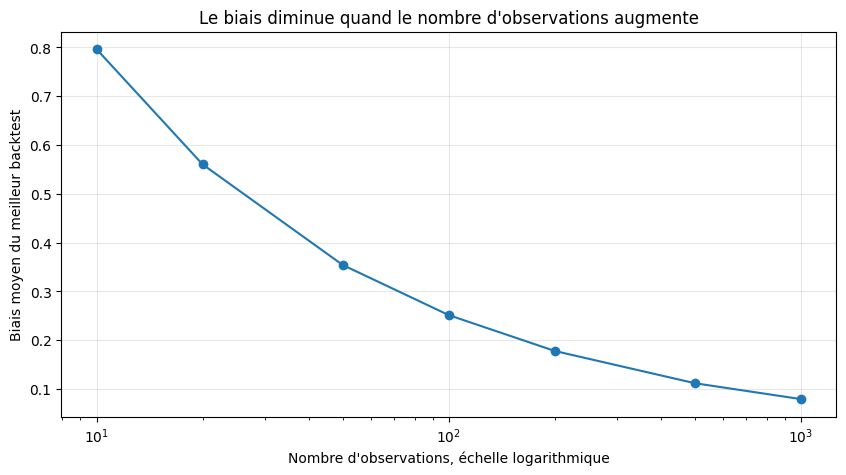

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(
    bias_by_obs["Nombre d'observations"],
    bias_by_obs["Biais moyen"],
    marker="o"
)
plt.xscale("log")
plt.title("Le biais diminue quand le nombre d'observations augmente")
plt.xlabel("Nombre d'observations, échelle logarithmique")
plt.ylabel("Biais moyen du meilleur backtest")
plt.grid(True, alpha=0.3)
plt.show()


## 5. Univers avec mérite variable

Un cas plus réaliste : toutes les règles n’ont pas le même mérite.

Certaines règles ont un vrai pouvoir prédictif, d’autres non.

Dans ce cas, le minage de données peut devenir utile, car il peut aider à découvrir une règle réellement supérieure.

Mais il reste conditionnel :

> Le minage de données devient une méthode de recherche honnête seulement si l’échantillon est assez grand pour distinguer le mérite réel du bruit.

On va simuler un univers où chaque règle a un mérite réel différent.


In [7]:
def simulate_variable_merit(
    n_rules=100,
    n_obs=100,
    merit_mean=0.0,
    merit_std=0.20,
    noise_std=1.0,
    n_experiments=3000,
):
    """
    Simule un univers où chaque règle possède un mérite réel différent.

    À chaque expérience :
    - les mérites réels des règles sont tirés d'une distribution ;
    - on observe des performances bruitées ;
    - on sélectionne la meilleure règle observée ;
    - on compare sa performance observée à son mérite réel.
    """
    true_merits = rng.normal(
        loc=merit_mean,
        scale=merit_std,
        size=(n_experiments, n_rules)
    )

    noise = rng.normal(
        loc=0.0,
        scale=noise_std,
        size=(n_experiments, n_rules, n_obs)
    )

    observed_means = true_merits[:, :, None] + noise
    observed_means = observed_means.mean(axis=2)

    best_idx = observed_means.argmax(axis=1)
    experiment_idx = np.arange(n_experiments)

    best_observed = observed_means[experiment_idx, best_idx]
    best_true_merit = true_merits[experiment_idx, best_idx]
    best_possible_true_merit = true_merits.max(axis=1)

    return pd.DataFrame({
        "best_observed_performance": best_observed,
        "true_merit_of_selected_rule": best_true_merit,
        "best_possible_true_merit": best_possible_true_merit,
        "data_mining_bias": best_observed - best_true_merit,
        "selection_efficiency": best_true_merit / best_possible_true_merit
    })

df_merit = simulate_variable_merit(n_rules=100, n_obs=100)

df_merit.describe()


,best_observed_performance,true_merit_of_selected_rule,best_possible_true_merit,data_mining_bias,selection_efficiency
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.560360,0.448626,0.501444,0.111734,0.889765
std,0.096077,0.119127,0.087532,0.092964,0.149543
min,0.302100,0.037630,0.240020,-0.238396,0.088819
25%,0.493520,0.363554,0.438667,0.049626,0.805678
50%,0.548868,0.443710,0.491932,0.110912,0.978170
75%,0.615009,0.524229,0.551782,0.175862,1.000000
max,0.996483,0.924571,0.924571,0.399016,1.000000


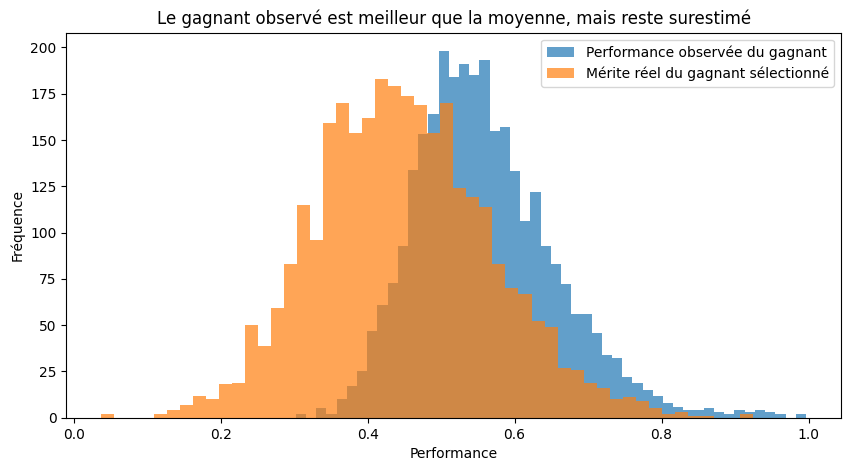

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(df_merit["best_observed_performance"], bins=50, alpha=0.7, label="Performance observée du gagnant")
plt.hist(df_merit["true_merit_of_selected_rule"], bins=50, alpha=0.7, label="Mérite réel du gagnant sélectionné")
plt.title("Le gagnant observé est meilleur que la moyenne, mais reste surestimé")
plt.xlabel("Performance")
plt.ylabel("Fréquence")
plt.legend()
plt.show()


## 6. Tableau de décision pour un trader quant

| Situation | Risque principal | Lecture EBTA |
|---|---:|---|
| Peu d’observations + beaucoup de règles | Très élevé | Le gagnant est probablement un outlier chanceux |
| Beaucoup d’observations + peu de règles | Faible à modéré | Le backtest est plus crédible |
| Beaucoup d’observations + beaucoup de règles | Gérable si correction statistique | Le minage peut devenir informatif |
| Règles très corrélées | Biais effectif plus faible | Le nombre réel de tests est plus petit |
| Règles indépendantes et nombreuses | Biais plus élevé | Plus d’occasions pour la chance |
| Univers avec vraies pépites | Minage potentiellement utile | Mais seulement avec assez de données |

> En trading algorithmique, la vraie question n’est pas : “Mon backtest est-il bon ?”  
> La vraie question est : “Combien de hasard a-t-il fallu pour obtenir ce backtest ?”


## 7. Application pratique EBTA

Pour rendre une recherche de stratégie plus scientifique :

1. **Compter le nombre de règles testées**

   Même les variantes de paramètres comptent comme des règles différentes.

2. **Mesurer le nombre d’observations effectives**

   Un backtest sur 5 ans en données 1 minute ne donne pas forcément autant d’observations indépendantes qu’il n’y paraît, car les signaux peuvent être fortement autocorrélés.

3. **Décoter la performance optimisée**

   Une performance issue d’une sélection doit être considérée comme trop optimiste.

4. **Utiliser un échantillon hors-sélection**

   Le hors-échantillon ne doit pas avoir été utilisé pour choisir la règle.

5. **Utiliser des corrections de comparaisons multiples**

   Exemples : **White’s Reality Check**, bootstrap, tests de robustesse, validation walk-forward.

6. **Chercher la stabilité plutôt que le pic**

   Une stratégie robuste n’est pas celle qui maximise parfaitement le passé. C’est celle qui reste correcte quand les hypothèses changent légèrement.


## 8. Mini-expérience : checklist de robustesse

Avant de croire une stratégie optimisée, pose-toi ces questions :

| Question | Pourquoi c’est important |
|---|---|
| Combien de règles ai-je réellement testées ? | Plus le nombre est grand, plus le biais augmente |
| Ai-je gardé une trace des essais échoués ? | Les échecs invisibles augmentent le biais caché |
| Le résultat survit-il à une variation des paramètres ? | Une stratégie fragile ressemble souvent à du hasard |
| La performance vient-elle de quelques trades extrêmes ? | Les outliers peuvent gonfler le backtest |
| Le comportement reste-t-il logique par régime de marché ? | Une règle valide doit avoir une raison économique ou comportementale |
| Le hors-échantillon est-il vraiment propre ? | Sinon il devient une extension déguisée du in-sample |

> Une stratégie solide n’a pas besoin d’être parfaite. Elle doit surtout survivre à l’inconfort statistique.


## 9. Conclusion

La synthèse d’Aronson est une leçon de discipline scientifique.

Le **data mining** n’est pas mauvais en soi. Il devient dangereux quand le trader oublie que la sélection transforme le backtest en résultat biaisé.

La performance passée du meilleur candidat contient deux choses :

$$
\text{Performance observée du gagnant}
=
\text{mérite réel}
+
\text{chance sélectionnée}
$$

Le rôle du quant n’est pas de supprimer toute recherche. C’est de construire un protocole capable de séparer l’or du métal des fous.

> **L’Eurêka final :** plus tu optimises, plus tu dois prouver. Le backtest n’est pas une preuve finale ; c’est une hypothèse qui doit survivre à la correction du hasard.


## Annexe — Texte source collé par l’utilisateur

Le texte ci-dessous est conservé comme source de travail pour garder la traçabilité pédagogique.


### **CH 6 : SUMMARY OF FINDINGS REGARDING THE DATA-MINING BIAS**

Cette section constitue la synthèse finale des recherches expérimentales menées par David Aronson sur le biais de minage. Elle récapitule les lois statistiques qui régissent la validité d'un backtest optimisé.

#### **Idées clés :**
*   **Biais Positif Systématique :** La règle sélectionnée par minage de données affiche toujours une performance passée supérieure à ce qu'elle produira réellement dans le futur.
*   **La Souveraineté de l'Échantillon :** Le nombre d'observations ($N$) est le facteur le plus puissant : plus il est élevé, plus le biais diminue car la distribution se resserre et les "queues" (outliers) s'allègent.
*   **La Rançon de la Recherche :** Plus le nombre de règles testées augmente, plus le biais de minage (le mensonge statistique) s'intensifie.
*   **Le Paradoxe de la Qualité :** Le biais est maximal lorsque toutes les règles testées ont un mérite faible ou identique ; il diminue si une règle est réellement supérieure aux autres.
*   **Efficacité Conditionnelle :** Le minage de données est une méthode de recherche valide qui permet de trouver de meilleures règles, mais uniquement si la taille de l'échantillon est suffisante.

#### **Référence :**
*Summary of Findings Regarding the Data-Mining Bias*, Chapitre 6, pages 319 à 320.

#### **Citation Directe :**
« The observed performance of a rule discovered by data mining—that is, the best performer in a set of back-tested rules—is positively biased. Its expected future return is less than its observed historical performance. » (Page 319).

---

#### **Vision Macro :**
L'enjeu est de transformer le minage de données d'un outil de "prophétie auto-réalisatrice" (où l'on finit toujours par trouver un profit par hasard) en une méthode de découverte scientifique. David Aronson insiste sur le fait que la détérioration de la performance hors-échantillon n'est pas une fatalité du marché, mais une conséquence mathématique prévisible du processus de sélection. Pour le trader, la question n'est pas « Est-ce que ce backtest est bon ? » mais « Combien de chance a-t-il fallu pour obtenir ce score ? ».

---

#### **Vision Micro :**
La synthèse d'Aronson repose sur cinq conclusions techniques issues de ses simulations Monte Carlo :

1.  **Mécanisme de chute :** La performance observée est "dopée" par le hasard lors de la compétition. Dès que la règle est appliquée à de nouvelles données, la part de "chance" s'évapore, ramenant le rendement vers son niveau de mérite réel.
2.  **Loi des Grands Nombres ($N$) :** L'augmentation des observations réduit la dispersion (variance) des résultats. Cela empêche les règles nulles d'atteindre accidentellement des scores extrêmes.
3.  **Inflation par le nombre :** Tester 1 000 règles au lieu de 10 multiplie les chances de tomber sur un outlier positif. Le seuil de significativité doit donc être relevé proportionnellement à l'intensité de la recherche.
4.  **Influence du mérite variable :** Si vous cherchez de l'or dans un tas de sable (mérite nul partout), le gagnant sera 100 % chanceux. Si vous cherchez dans un tas contenant une vraie pépite (mérite élevé), le minage l'identifiera avec moins de biais résiduel.
5.  **Validation du minage intensif :** Aronson confirme que "plus on cherche, plus on trouve" de la qualité ($ER$ élevé), mais seulement si l'on a assez de données pour filtrer le bruit. Sans masse de données, le minage est une perte de temps.

---

#### **Résumé Simplifié :**
Le minage de données est comme un scanner qui cherche des trésors. Il est très efficace pour désigner la "meilleure" règle, mais il a un gros défaut : il surestime toujours la valeur du trésor car il confond la poussière (le hasard) avec l'or (le mérite). Plus vous scannez d'objets (règles) sur un petit tas de terre (échantillon court), plus le scanner va mentir. Pour qu'il dise la vérité, il lui faut des montagnes de données.

---

#### **Exemple du livre pour mieux comprendre :**
*   **L'expérience des 1 024 ATR :** Aronson rappelle que sur seulement **10 mois** de données, le biais pour le meilleur candidat est de **84 %** (un mensonge presque total). En passant à **1 000 mois**, ce biais chute à moins de **12 %**, prouvant que le temps est le seul remède contre l'illusion statistique.

---

#### **Actions Concrètes :**
*   **Appliquer une décote :** Soustrayez systématiquement une part de profit à vos backtests optimisés avant de risquer du capital.
*   **Prioriser $N$ sur tout le reste :** N'ajoutez pas de nouvelles règles ou de nouveaux indicateurs si vous n'avez pas un échantillon assez large pour "encaisser" le biais supplémentaire.
*   **Utiliser des tests de "Reality Check" :** Puisque le biais est inévitable, utilisez des outils comme le *White's Reality Check* pour calculer si le profit observé survit à la correction pour comparaisons multiples.

---

#### **À retenir absolument :**
*   Le profit réel sera **toujours inférieur** au backtest optimisé.
*   Le **nombre d'observations** est le régulateur principal du biais.
*   Tester trop de règles sur trop peu de données produit du **"métal des fous"**.
*   Le minage de données ne devient une **méthode honnête** qu'avec de grands échantillons.
*   La chance ne se répète pas : ce qui a gagné par "coup de bol" perdra dans le futur.

J'ai terminé la synthèse des conclusions sur le biais de minage selon le protocole EBTA.
